# `logical_rb` — Tests and Usage Guide

Each section tests one module and shows how to use its public interface.
Run cells top-to-bottom; later sections depend on earlier ones.

In [2]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

RNG = np.random.default_rng(42)

---
## 1. `operators.py`

Primitive matrices, tensor-product helpers, and environment state construction.

In [3]:
from logical_rb.operators import I2, X, Y, Z, H, S, Sd

# --- Pauli algebra: σ_i σ_j = iε_{ijk} σ_k ---
assert np.allclose(X @ Y, 1j * Z), "XY = iZ"
assert np.allclose(Y @ Z, 1j * X), "YZ = iX"
assert np.allclose(Z @ X, 1j * Y), "ZX = iY"

# Each Pauli squares to identity
for name, P in [("X", X), ("Y", Y), ("Z", Z)]:
    assert np.allclose(P @ P, I2), f"{name}^2 = I"

# Pauli matrices are Hermitian
for name, P in [("X", X), ("Y", Y), ("Z", Z)]:
    assert np.allclose(P, P.conj().T), f"{name} must be Hermitian"

# H is its own inverse
assert np.allclose(H @ H, I2), "H^2 = I"

# S† = S^{-1}
assert np.allclose(S @ Sd, I2), "S S† = I"
assert np.allclose(Sd @ S, I2), "S† S = I"

# H diagonalises X: H X H = Z
assert np.allclose(H @ X @ H, Z), "H X H = Z"

# S Z S† = Z  (S is diagonal, commutes with Z)
assert np.allclose(S @ Z @ Sd, Z), "S Z S† = Z"

print("Pauli / gate identities: OK")

Pauli / gate identities: OK


In [4]:
from logical_rb.operators import kron_list, lift, lift_to_sys_env, pauli_string

# kron_list: left-to-right Kronecker product
XI = kron_list([X, I2])
IX = kron_list([I2, X])
assert XI.shape == (4, 4)
assert IX.shape == (4, 4)
assert not np.allclose(XI, IX), "XI ≠ IX"

# kron_list with one element = that element
assert np.allclose(kron_list([Z]), Z)

# kron_list with zero elements = 1×1 identity
assert np.allclose(kron_list([]), np.ones((1, 1)))

# lift: G on qubit q in an n-qubit register
X_on_0 = lift(X, qubit=0, n_total=2)   # X ⊗ I
X_on_1 = lift(X, qubit=1, n_total=2)   # I ⊗ X
assert np.allclose(X_on_0, XI)
assert np.allclose(X_on_1, IX)

# lift in a 3-qubit register
Z_on_1 = lift(Z, qubit=1, n_total=3)   # I ⊗ Z ⊗ I
expected = kron_list([I2, Z, I2])
assert np.allclose(Z_on_1, expected)

# pauli_string: multi-site operator, unspecified qubits get identity
ZZ = pauli_string([(Z, 0), (Z, 2)], n_total=3)  # Z ⊗ I ⊗ Z
expected = kron_list([Z, I2, Z])
assert np.allclose(ZZ, expected)

# pauli_string with no sites = identity
identity_3 = pauli_string([], n_total=3)
assert np.allclose(identity_3, np.eye(8))

# lift_to_sys_env: embeds a system operator into S⊗E space
Z_sys = lift_to_sys_env(Z, n_sys=1, n_E=2)   # Z_S ⊗ I_{E,4x4}
assert Z_sys.shape == (8, 8)
expected = kron_list([Z, np.eye(4)])
assert np.allclose(Z_sys, expected)

print("kron_list / lift / pauli_string / lift_to_sys_env: OK")

kron_list / lift / pauli_string / lift_to_sys_env: OK


In [5]:
from logical_rb.operators import env_zero_state

# n_E = 0: trivial 1-element state
e0 = env_zero_state(0)
assert e0.shape == (1,) and np.isclose(e0[0], 1.0)

# n_E = 1: |0>
e1 = env_zero_state(1)
assert np.allclose(e1, [1, 0])

# n_E = 2: |00>
e2 = env_zero_state(2)
assert e2.shape == (4,) and np.isclose(e2[0], 1.0) and np.allclose(e2[1:], 0)

print("env_zero_state: OK")

env_zero_state: OK


In [6]:
from logical_rb.operators import partial_trace_env

# 1. Product state |psi_S> ⊗ |phi_E>: Tr_E[rho_SE] must equal rho_S = |psi_S><psi_S|
psi_s = np.array([1, 1], dtype=complex) / np.sqrt(2)   # |+>_S
phi_e = np.array([1, 0], dtype=complex)                  # |0>_E
psi_se = np.kron(psi_s, phi_e)
rho_se = np.outer(psi_se, psi_se.conj())

rho_s = partial_trace_env(rho_se, n_sys=1, n_E=1)
rho_s_expected = np.outer(psi_s, psi_s.conj())
assert rho_s.shape == (2, 2), f"Expected (2,2), got {rho_s.shape}"
assert np.allclose(rho_s, rho_s_expected, atol=1e-12), "Product-state partial trace wrong"

# 2. Bell state |Phi+> = (|00>+|11>)/sqrt(2): Tr_E[rho] = I/2 (maximally mixed)
phi_plus = np.array([1, 0, 0, 1], dtype=complex) / np.sqrt(2)
rho_bell = np.outer(phi_plus, phi_plus.conj())
rho_s_bell = partial_trace_env(rho_bell, n_sys=1, n_E=1)
assert np.allclose(rho_s_bell, np.eye(2) / 2, atol=1e-12), "Bell-state partial trace should be I/2"

# 3. Trace preservation: Tr[rho_S] = 1 whenever Tr[rho_SE] = 1
rng_t = np.random.default_rng(13)
A_rand = rng_t.standard_normal((4, 4)) + 1j * rng_t.standard_normal((4, 4))
rho_rand = A_rand @ A_rand.conj().T
rho_rand /= np.trace(rho_rand)
rho_s_rand = partial_trace_env(rho_rand, n_sys=1, n_E=1)
assert np.isclose(np.trace(rho_s_rand).real, 1.0, atol=1e-12), "Partial trace not trace-preserving"

# 4. n_E=0 is trivial: environment is 1-dimensional, so Tr_E = identity map
rho_s_only = np.outer(psi_s, psi_s.conj())
rho_s_back = partial_trace_env(rho_s_only, n_sys=1, n_E=0)
assert np.allclose(rho_s_back, rho_s_only, atol=1e-12), "n_E=0 partial trace should be identity"

print("partial_trace_env: product state, Bell state, trace preservation, n_E=0: OK")

partial_trace_env: product state, Bell state, trace preservation, n_E=0: OK


---
## 2. `cliffords.py`

24-element single-qubit Clifford group, inverse lookup, random sequence generation.

In [7]:
from logical_rb.cliffords import (
    CLIFFORDS, generate_clifford_group,
    clifford_inverse, find_recovery_gate, sample_sequence,
)

# Exactly 24 elements
assert len(CLIFFORDS) == 24, f"Expected 24 Cliffords, got {len(CLIFFORDS)}"

# Every element is unitary
for i, C in enumerate(CLIFFORDS):
    err = np.linalg.norm(C.conj().T @ C - I2)
    assert err < 1e-10, f"Clifford {i} is not unitary (err={err:.2e})"

# Group closure: product of any two Cliffords is in the group (modulo phase)
# We just check a few random pairs
rng_test = np.random.default_rng(7)
from logical_rb.cliffords import _matrix_key, _KEY_TO_IDX
for _ in range(20):
    a, b = rng_test.integers(0, 24, size=2)
    product = CLIFFORDS[a] @ CLIFFORDS[b]
    key = _matrix_key(product)
    assert key in _KEY_TO_IDX, f"Clifford[{a}] @ Clifford[{b}] not in group"

print(f"Clifford group: {len(CLIFFORDS)} elements, all unitary, closed under product. OK")

Clifford group: 24 elements, all unitary, closed under product. OK


In [8]:
# clifford_inverse: C_inv such that C_inv @ C ≈ exp(iφ) I
for i, C in enumerate(CLIFFORDS):
    C_inv = clifford_inverse(C)
    product = C_inv @ C
    # Must be proportional to identity
    ratio = product[0, 0]
    assert abs(ratio) > 1e-10, f"Clifford {i}: C_inv@C has zero diagonal"
    assert np.allclose(product, ratio * I2, atol=1e-9), (
        f"Clifford {i}: C_inv@C is not a scalar multiple of I"
    )
    # The scalar must be a unit complex number
    assert np.isclose(abs(ratio), 1.0, atol=1e-9), (
        f"Clifford {i}: C_inv@C scalar has |scalar|={abs(ratio):.4f} ≠ 1"
    )

print("clifford_inverse: C_inv @ C = exp(iφ) I for all 24 Cliffords. OK")

clifford_inverse: C_inv @ C = exp(iφ) I for all 24 Cliffords. OK


In [9]:
# find_recovery_gate: the last gate in an RB sequence
# After applying all gates INCLUDING the recovery, the net operation
# must be proportional to identity.
rng_test = np.random.default_rng(17)

for trial in range(30):
    m = rng_test.integers(1, 12)
    seq = sample_sequence(int(m), rng_test)
    recovery = find_recovery_gate(seq)

    # Accumulated gate
    U = I2.copy()
    for C in seq:
        U = C @ U

    # recovery @ U must be proportional to I
    result = recovery @ U
    ratio = result[0, 0]
    assert abs(ratio) > 1e-10
    assert np.allclose(result, ratio * I2, atol=1e-9), (
        f"Trial {trial}: recovery @ U is not scalar*I"
    )
    assert np.isclose(abs(ratio), 1.0, atol=1e-9)

print("find_recovery_gate: recovery @ (Cm @ ... @ C1) = exp(iφ) I for 30 random sequences. OK")

find_recovery_gate: recovery @ (Cm @ ... @ C1) = exp(iφ) I for 30 random sequences. OK


In [12]:
# sample_sequence: uniform sampling, all 24 Cliffords should appear
rng_test = np.random.default_rng(99)
big_seq = sample_sequence(2400, rng_test)
assert len(big_seq) == 2400

# Each element must be in the group
for c in big_seq:
    assert _matrix_key(c) in _KEY_TO_IDX

# Count occurrences of each Clifford — should be roughly 100 each
counts = [0] * 24
for c in big_seq:
    counts[_KEY_TO_IDX[_matrix_key(c)]] += 1
assert min(counts) > 40, "Some Clifford never sampled — likely biased sampling"
assert max(counts) < 180, "Some Clifford heavily oversampled — likely biased"

print(f"sample_sequence: counts per Clifford range [{min(counts)}, {max(counts)}] (expected ~100). OK")

sample_sequence: counts per Clifford range [85, 119] (expected ~100). OK


---
## 3. `codes.py`

### 3a. `RepetitionCode` (3-qubit, corrects single bit-flip)

In [14]:
from logical_rb.codes import RepetitionCode

rep = RepetitionCode()

# Codewords
zero = rep.encode_zero()   # |000>
one  = rep.encode_one()    # |111>

assert np.allclose(zero, [1,0,0,0,0,0,0,0]), "|0_L> should be |000>"
assert np.allclose(one,  [0,0,0,0,0,0,0,1]), "|1_L> should be |111>"
assert np.isclose(np.vdot(zero, one), 0.0),   "Codewords must be orthogonal"

# Stabilizers fix both codewords
for stab in rep.stabilizers:
    assert np.allclose(stab @ zero, zero), "Z0Z1 or Z1Z2 must stabilize |0_L>"
    assert np.allclose(stab @ one,  one),  "Z0Z1 or Z1Z2 must stabilize |1_L>"

# Logical-Z eigenvalues: +1 for |0_L>, -1 for |1_L>
assert np.allclose(rep.logical_z @ zero,  zero), "Z_L|0_L> = +|0_L>"
assert np.allclose(rep.logical_z @ one,  -one),  "Z_L|1_L> = -|1_L>"

# Logical-X swaps codewords
assert np.allclose(rep.logical_x @ zero, one),  "X_L|0_L> = |1_L>"
assert np.allclose(rep.logical_x @ one,  zero), "X_L|1_L> = |0_L>"

print("RepetitionCode codewords, stabilizers, logical Paulis: OK")

RepetitionCode codewords, stabilizers, logical Paulis: OK


In [15]:
from logical_rb.operators import kron_list

X0 = kron_list([X, I2, I2])
X1 = kron_list([I2, X, I2])
X2 = kron_list([I2, I2, X])

# Inject a single-qubit X error; syndrome + recovery must return to codespace
errors = [
    (np.eye(8, dtype=complex), (0, 0), "no error"),
    (X0,                       (1, 0), "X on qubit 0"),
    (X1,                       (1, 1), "X on qubit 1"),
    (X2,                       (0, 1), "X on qubit 2"),
]

for E, expected_syndrome, label in errors:
    corrupted = E @ zero

    # Compute syndrome by hand: bit=1 means eigenvalue -1
    syndrome = tuple(
        0 if np.isclose(np.vdot(corrupted, stab @ corrupted).real, 1.0) else 1
        for stab in rep.stabilizers
    )

    assert syndrome == expected_syndrome, (
        f"{label}: expected syndrome {expected_syndrome}, got {syndrome}"
    )

    recovery = rep.recovery(syndrome)
    corrected = recovery @ corrupted

    # After correction, the state must be back in the code space (overlap with |0_L> or |1_L>)
    overlap_0 = abs(np.vdot(zero, corrected))
    overlap_1 = abs(np.vdot(one,  corrected))
    assert np.isclose(overlap_0**2 + overlap_1**2, 1.0, atol=1e-9), (
        f"{label}: corrected state not in code space"
    )

print("RepetitionCode.recovery: correct syndromes and correction for all single-bit errors. OK")

RepetitionCode.recovery: correct syndromes and correction for all single-bit errors. OK


In [16]:
# logical_unitary: extends a 2x2 gate to the physical code space
# Applying logical X should swap |0_L> and |1_L>
phys_X = rep.logical_unitary(X)

assert np.allclose(phys_X @ zero, one,  atol=1e-9), "phys_X |0_L> = |1_L>"
assert np.allclose(phys_X @ one,  zero, atol=1e-9), "phys_X |1_L> = |0_L>"

# logical H should map |0_L> -> (|0_L>+|1_L>)/sqrt(2)
phys_H = rep.logical_unitary(H)
plus_L = (zero + one) / np.sqrt(2)
assert np.allclose(phys_H @ zero, plus_L, atol=1e-9), "phys_H |0_L> = |+_L>"

# The physical extension must be unitary on the full 8-dimensional space
dim = 2**rep.n
err = np.linalg.norm(phys_X.conj().T @ phys_X - np.eye(dim))
assert err < 1e-9, f"phys_X not unitary: err={err:.2e}"

print("RepetitionCode.logical_unitary: OK")

RepetitionCode.logical_unitary: OK


### 3b. `SteaneCode` ([[7,1,3]] CSS code)

In [17]:
from logical_rb.codes import SteaneCode

steane = SteaneCode()

zero7 = steane.encode_zero()
one7  = steane.encode_one()

assert zero7.shape == (128,), f"Expected shape (128,), got {zero7.shape}"
assert np.isclose(np.linalg.norm(zero7), 1.0), "|0_L> not normalized"
assert np.isclose(np.linalg.norm(one7),  1.0), "|1_L> not normalized"
assert np.isclose(np.vdot(zero7, one7), 0.0, atol=1e-9), "Codewords not orthogonal"

# All 6 stabilizers fix both codewords
for i, stab in enumerate(steane.stabilizers):
    err0 = np.linalg.norm(stab @ zero7 - zero7)
    err1 = np.linalg.norm(stab @ one7  - one7)
    assert err0 < 1e-9, f"Stabilizer {i} does not fix |0_L>: err={err0:.2e}"
    assert err1 < 1e-9, f"Stabilizer {i} does not fix |1_L>: err={err1:.2e}"

# Logical-Z eigenvalues
assert np.allclose(steane.logical_z @ zero7,  zero7, atol=1e-9), "Z_L |0_L> = +|0_L>"
assert np.allclose(steane.logical_z @ one7,  -one7,  atol=1e-9), "Z_L |1_L> = -|1_L>"

# Logical-X swaps codewords
assert np.allclose(steane.logical_x @ zero7, one7,  atol=1e-9), "X_L |0_L> = |1_L>"
assert np.allclose(steane.logical_x @ one7,  zero7, atol=1e-9), "X_L |1_L> = |0_L>"

print("SteaneCode codewords, stabilizers, logical Paulis: OK")

SteaneCode codewords, stabilizers, logical Paulis: OK


In [18]:
from logical_rb.operators import pauli_string

# Syndrome convention: stabilizers = z_stabs + x_stabs
# z_stabs detect X errors; x_stabs detect Z errors
# syndrome bit = 1 means eigenvalue -1

def measure_syndrome(state, stabilizers):
    bits = []
    for stab in stabilizers:
        ev = np.vdot(state, stab @ state).real
        bits.append(0 if np.isclose(ev, 1.0, atol=1e-6) else 1)
    return tuple(bits)

# For Hamming decoding: X error on qubit k (0-indexed) should map
# to z_syndrome = binary rep of (k+1) via bits s0 + 2*s1 + 4*s2
for k in range(7):
    E_x = pauli_string([(X, k)], n_total=7)
    corrupted = E_x @ zero7
    syndrome = measure_syndrome(corrupted, steane.stabilizers)

    # Check z_syndrome encodes qubit k+1 in binary
    z_s = syndrome[:3]
    index = z_s[0] + 2*z_s[1] + 4*z_s[2]
    assert index == k + 1, (
        f"X error on qubit {k}: expected z-index {k+1}, got {index} "
        f"(syndrome={syndrome})"
    )

    # x_syndrome must be all zeros (X errors don't trigger X stabilizers)
    assert syndrome[3:] == (0, 0, 0), (
        f"X error on qubit {k} triggered X stabilizers: x_syndrome={syndrome[3:]}"
    )

    # Apply recovery and check we're back in the code space
    recovery = steane.recovery(syndrome)
    corrected = recovery @ corrupted
    overlap = abs(np.vdot(zero7, corrected))**2
    assert np.isclose(overlap, 1.0, atol=1e-9), (
        f"Recovery failed for X error on qubit {k}: overlap={overlap:.6f}"
    )

# Same for Z errors
for k in range(7):
    E_z = pauli_string([(Z, k)], n_total=7)
    corrupted = E_z @ zero7
    syndrome = measure_syndrome(corrupted, steane.stabilizers)

    # z_syndrome must be all zeros (Z errors don't trigger Z stabilizers)
    assert syndrome[:3] == (0, 0, 0), (
        f"Z error on qubit {k} triggered Z stabilizers: z_syndrome={syndrome[:3]}"
    )

    x_s = syndrome[3:]
    index = x_s[0] + 2*x_s[1] + 4*x_s[2]
    assert index == k + 1, (
        f"Z error on qubit {k}: expected x-index {k+1}, got {index}"
    )

    recovery = steane.recovery(syndrome)
    corrected = recovery @ corrupted
    # Z error maps |0_L> to itself (Z|0_L> = |0_L> up to global phase via logical Z)
    # After Z correction the state should still be in code space
    overlap = abs(np.vdot(zero7, corrected))**2
    assert np.isclose(overlap, 1.0, atol=1e-9), (
        f"Recovery failed for Z error on qubit {k}: overlap={overlap:.6f}"
    )

print("SteaneCode.recovery: correct CSS decoding for all 7 X-errors and 7 Z-errors. OK")

SteaneCode.recovery: correct CSS decoding for all 7 X-errors and 7 Z-errors. OK


In [19]:
# Logical H should map |0_L> -> |+_L> = (|0_L>+|1_L>)/sqrt(2)
phys_H7 = steane.logical_unitary(H)
plus_L7 = (zero7 + one7) / np.sqrt(2)

# Check it's unitary on the full 128-dim space
err_unit = np.linalg.norm(phys_H7.conj().T @ phys_H7 - np.eye(128))
assert err_unit < 1e-9, f"phys_H7 not unitary: {err_unit:.2e}"

# Check action on codewords
result = phys_H7 @ zero7
overlap_plus = abs(np.vdot(plus_L7, result))
assert np.isclose(overlap_plus, 1.0, atol=1e-9), (
    f"phys_H7 |0_L> not equal to |+_L>: overlap={overlap_plus:.6f}"
)

# Logical X via logical_unitary must swap codewords
phys_X7 = steane.logical_unitary(X)
assert np.allclose(phys_X7 @ zero7, one7,  atol=1e-9)
assert np.allclose(phys_X7 @ one7,  zero7, atol=1e-9)

print("SteaneCode.logical_unitary (H, X): OK")

SteaneCode.logical_unitary (H, X): OK


---
## 4. `noise_models.py`

System-environment coupling unitaries.

In [20]:
from logical_rb.noise_models import hamiltonian_coupling

# exp(-i H tau) must be unitary for any Hermitian H
# Use a random 4x4 Hermitian
rng_t = np.random.default_rng(5)
A = rng_t.standard_normal((4, 4)) + 1j * rng_t.standard_normal((4, 4))
H_test = (A + A.conj().T) / 2

U = hamiltonian_coupling(H_test, tau=0.5)
assert U.shape == (4, 4)
err = np.linalg.norm(U.conj().T @ U - np.eye(4))
assert err < 1e-10, f"hamiltonian_coupling not unitary: {err:.2e}"

# tau=0 must give the identity
U0 = hamiltonian_coupling(H_test, tau=0.0)
assert np.allclose(U0, np.eye(4), atol=1e-10)

# exp(-i H tau) and exp(+i H tau) are inverses
U_plus  = hamiltonian_coupling(H_test, tau=+0.3)
U_minus = hamiltonian_coupling(H_test, tau=-0.3)
assert np.allclose(U_plus @ U_minus, np.eye(4), atol=1e-9)

# Non-Hermitian input must be rejected
try:
    hamiltonian_coupling(A, tau=0.5)   # A is not Hermitian
    assert False, "Should have raised ValueError"
except ValueError:
    pass

print("hamiltonian_coupling: unitary, identity at tau=0, rejects non-Hermitian input. OK")

hamiltonian_coupling: unitary, identity at tau=0, rejects non-Hermitian input. OK


In [21]:
from logical_rb.noise_models import ising_coupling, xx_coupling

def check_unitary(U, name):
    n = U.shape[0]
    err = np.linalg.norm(U.conj().T @ U - np.eye(n))
    assert err < 1e-9, f"{name} not unitary: {err:.2e}"

# ising_coupling: H_SE = J sum_k Z_k Z_E0
# n_sys=3, n_E=1 -> 4 qubits, 16x16 matrix
U_ising = ising_coupling(n_sys=3, n_E=1, J=0.2, tau=0.4)
assert U_ising.shape == (16, 16)
check_unitary(U_ising, "ising_coupling")

# J=0 must give identity (no coupling)
U_ising_0 = ising_coupling(n_sys=2, n_E=1, J=0.0, tau=1.0)
assert np.allclose(U_ising_0, np.eye(8), atol=1e-10), "J=0 should give identity"

# xx_coupling: H_SE = g sum_k (X_k X_E0 + Y_k Y_E0)
U_xx = xx_coupling(n_sys=3, n_E=1, g=0.15, tau=0.5)
assert U_xx.shape == (16, 16)
check_unitary(U_xx, "xx_coupling")

# g=0 must give identity
U_xx_0 = xx_coupling(n_sys=2, n_E=1, g=0.0, tau=1.0)
assert np.allclose(U_xx_0, np.eye(8), atol=1e-10), "g=0 should give identity"

print("ising_coupling / xx_coupling: shape, unitarity, identity at zero coupling. OK")

ising_coupling / xx_coupling: shape, unitarity, identity at zero coupling. OK


In [22]:
from logical_rb.noise_models import random_unitary, partial_swap, cnot_env_coupling, kraus_from_USE

# random_unitary
U_rand = random_unitary(n_sys=2, n_E=1, strength=0.3, seed=42)
assert U_rand.shape == (8, 8)
check_unitary(U_rand, "random_unitary")

# strength=0 must give identity
U_rand0 = random_unitary(n_sys=2, n_E=1, strength=0.0, seed=1)
assert np.allclose(U_rand0, np.eye(8), atol=1e-10)

# partial_swap: theta=0 -> identity; theta=pi/2 -> full SWAP (up to global phase)
U_pswap_0 = partial_swap(n_sys=1, n_E=1, theta=0.0)
assert np.allclose(U_pswap_0, np.eye(4), atol=1e-10), "partial_swap(theta=0) should be I"

U_pswap = partial_swap(n_sys=1, n_E=1, theta=0.3)
check_unitary(U_pswap, "partial_swap")

# cnot_env_coupling
U_cnot = cnot_env_coupling(n_sys=1, n_E=1, theta_env=0.5)
assert U_cnot.shape == (4, 4)
check_unitary(U_cnot, "cnot_env_coupling")

# theta_env=0 -> Ry(0) = I, so only CNOT remains
U_cnot_0 = cnot_env_coupling(n_sys=1, n_E=1, theta_env=0.0)
# CNOT_{S0->E0} with S0 leftmost: |00>->|00>, |01>->|01>, |10>->|11>, |11>->|10>
CNOT_expected = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)
assert np.allclose(U_cnot_0, CNOT_expected, atol=1e-10), (
    f"cnot_env_coupling(theta=0) should be CNOT, got:\n{np.round(U_cnot_0.real, 3)}"
)

print("random_unitary / partial_swap / cnot_env_coupling: OK")

random_unitary / partial_swap / cnot_env_coupling: OK


In [23]:
# kraus_from_USE: extract Kraus operators, verify trace-preservation
U_test = ising_coupling(n_sys=2, n_E=2, J=0.1, tau=0.3)
kraus_ops = kraus_from_USE(U_test, n_sys=2, n_E=2)

# Number of Kraus operators = dim_E = 2^n_E = 4
assert len(kraus_ops) == 4, f"Expected 4 Kraus operators, got {len(kraus_ops)}"

# Each Kraus operator has shape (dim_S, dim_S) = (4, 4)
for k, K in enumerate(kraus_ops):
    assert K.shape == (4, 4), f"K_{k} shape wrong: {K.shape}"

# Completeness: sum_k K_k† K_k = I_S
completeness = sum(K.conj().T @ K for K in kraus_ops)
err = np.linalg.norm(completeness - np.eye(4))
assert err < 1e-9, f"Kraus operators not trace-preserving: {err:.2e}"

# The channel should not be unitary in general (because E gets entangled)
# but for J=0 it collapses to identity channel: all K_k should be scalar multiples of I_S
U_trivial = ising_coupling(n_sys=2, n_E=1, J=0.0, tau=1.0)
kraus_trivial = kraus_from_USE(U_trivial, n_sys=2, n_E=1)
# Only K_0 should be nonzero (= I_S), K_1 should be zero
assert np.allclose(kraus_trivial[0], np.eye(4), atol=1e-9), "J=0: K_0 should be I_S"
assert np.allclose(kraus_trivial[1], np.zeros((4,4)), atol=1e-9), "J=0: K_1 should be 0"

print("kraus_from_USE: correct shape, trace-preserving, identity channel at J=0. OK")

kraus_from_USE: correct shape, trace-preserving, identity channel at J=0. OK


---
## 5. `engine.py`

The engine computes **exact** survival probabilities — no Monte Carlo, no shots.

### How it works

For each LRB sequence the engine evolves a density matrix through m+1 gate–noise–QEC
cycles and returns `Tr[(|0_L⟩⟨0_L| ⊗ I_E) ρ_final]`.

The QEC step is applied as an **exact Kraus channel**:

$$\Lambda_{\rm QEC}(\rho) = \sum_s K_s \rho K_s^\dagger, \qquad K_s = R(s)\,\Pi_s$$

where the sum runs over all $2^{n_{\rm stabs}}$ syndrome bit-patterns simultaneously.
This marginalises over every possible measurement outcome in one deterministic step —
no syndrome Born-sampling is needed.

### Noise models

| Class | Environment | `reset_E` effect |
|---|---|---|
| `UnitarySENoise(U_SE, n_E)` | Explicit quantum register persists across cycles | Exact partial-trace reset after each QEC |
| `MarkovianKraus(kraus_ops)` | None | Ignored |
| `TimeVaryingKraus(kraus_ops_list)` | None | Ignored |

### 5a. Zero-noise sanity check

In [27]:
from logical_rb import run_logical_rb, rb_sequence_survival
from logical_rb import UnitarySENoise, MarkovianKraus, TimeVaryingKraus
from logical_rb.codes import RepetitionCode

rep = RepetitionCode()

# --- MarkovianKraus with identity channel = zero noise ---
# No environment needed; the Kraus channel is just {I_S}.
identity_noise = MarkovianKraus([np.eye(2**rep.n, dtype=complex)])

p_zero = rb_sequence_survival(m=10, code=rep, noise=identity_noise, rng=np.random.default_rng(0))
assert p_zero > 0.99999, f"Noiseless: expected survival 1.0, got {p_zero}"

results_noiseless = run_logical_rb(
    sequence_lengths=[1, 3, 5, 10],
    num_sequences=20,
    code=rep,
    noise=identity_noise,
    seed=0,
)

means = results_noiseless["survival_means"]
stds  = results_noiseless["survival_stds"]
assert np.all(means > 0.99), f"Noiseless RB: expected survival ~1, got {means}"
assert np.all(stds  < 1e-9), f"Noiseless RB: expected std=0, got {stds}"

print(f"Zero-noise (MarkovianKraus identity): survival = 1.0 for all lengths. OK")

Zero-noise (MarkovianKraus identity): survival = 1.0 for all lengths. OK


In [38]:
from logical_rb.noise_models import xx_coupling

# --- UnitarySENoise: persistent SE environment ---
U_noisy = xx_coupling(n_sys=rep.n, n_E=1, g=0.4, tau=0.5)
noise_se = UnitarySENoise(U_noisy, n_E=1)

lengths = [1, 3, 6, 12, 20]

results_nm = run_logical_rb(
    sequence_lengths=lengths,
    num_sequences=1000,
    code=rep,
    noise=noise_se,
    reset_E=False,
    seed=1,
)

means = results_nm["survival_means"]
print(f"  NM survival means (exact, no shots): {np.round(means, 3)}")

assert means[0] > means[-1], f"Expected decay: first={means[0]:.3f}, last={means[-1]:.3f}"
assert np.all((results_nm["all_survivals"] >= 0.0) & (results_nm["all_survivals"] <= 1.0))

# Output keys
expected_keys = {"sequence_lengths", "survival_means", "survival_stds",
                 "survival_sems", "all_survivals", "all_seq_means",
                 "reset_E", "code_name", "noise_type"}
assert expected_keys.issubset(results_nm.keys())
assert results_nm["noise_type"] == "UnitarySENoise"

print("run_logical_rb (UnitarySENoise): decay, exact values, output keys. OK")

  NM survival means (exact, no shots): [0.923 0.806 0.684 0.569 0.518]
run_logical_rb (UnitarySENoise): decay, exact values, output keys. OK


In [39]:
# --- Markovian reference (reset_E=True) ---
# After every QEC cycle: rho_SE -> Tr_E[rho_SE] ⊗ |0><0|_E  (exact, deterministic).
# Same Clifford sequences as NM run (same seed).

results_mk = run_logical_rb(
    sequence_lengths=lengths,
    num_sequences=1000,
    code=rep,
    noise=noise_se,
    reset_E=True,
    seed=1,
)

print(f"  NM survival means: {np.round(results_nm['survival_means'], 3)}")
print(f"  MK survival means: {np.round(results_mk['survival_means'], 3)}")

# --- MarkovianKraus: extract Kraus ops from U_SE ---
# The Markovian Kraus channel Λ(ρ_S) = Σ_k K_k ρ_S K_k† is mathematically
# equivalent to running the SE unitary and tracing out E (from |0>_E).
# It gives a system-only description of the Markovian noise.
from logical_rb import kraus_from_USE

kraus_ops = kraus_from_USE(U_noisy, n_sys=rep.n, n_E=1)
noise_kraus = MarkovianKraus(kraus_ops)

results_kraus = run_logical_rb(
    sequence_lengths=lengths,
    num_sequences=30,
    code=rep,
    noise=noise_kraus,
    seed=1,
)
print(f"  MarkovianKraus means: {np.round(results_kraus['survival_means'], 3)}")
assert results_kraus["noise_type"] == "MarkovianKraus"

# --- TimeVaryingKraus: different Kraus ops per cycle ---
# Two-cycle pattern: alternate between U_noisy Kraus ops and identity
noise_tv = TimeVaryingKraus([kraus_ops, [np.eye(2**rep.n, dtype=complex)]])
results_tv = run_logical_rb(
    sequence_lengths=lengths,
    num_sequences=30,
    code=rep,
    noise=noise_tv,
    seed=1,
)
print(f"  TimeVaryingKraus means: {np.round(results_tv['survival_means'], 3)}")
assert results_tv["noise_type"] == "TimeVaryingKraus"
assert results_tv["survival_means"][0] > results_tv["survival_means"][-1]

print("All three noise models run and decay correctly. OK")

  NM survival means: [0.923 0.806 0.684 0.569 0.518]
  MK survival means: [0.923 0.806 0.684 0.569 0.518]
  MarkovianKraus means: [0.931 0.82  0.673 0.57  0.522]
  TimeVaryingKraus means: [0.931 0.865 0.801 0.701 0.607]
All three noise models run and decay correctly. OK


In [40]:
# rb_sequence_survival: returns one exact float, no trajectories
p = rb_sequence_survival(
    m=5,
    code=rep,
    noise=noise_se,
    reset_E=False,
    rng=np.random.default_rng(7),
)

assert isinstance(p, float), f"Expected float, got {type(p)}"
assert 0.0 <= p <= 1.0, f"Survival out of [0,1]: {p}"
print(f"rb_sequence_survival: p = {p:.4f}  (single exact value, no shots). OK")

# Calling with the same RNG state / same explicit gates gives the same result
from logical_rb.cliffords import sample_sequence, find_recovery_gate
rng_det = np.random.default_rng(99)
seq = sample_sequence(5, rng_det)
gates = seq + [find_recovery_gate(seq)]

p1 = rb_sequence_survival(m=5, code=rep, noise=noise_se, gates=gates)
p2 = rb_sequence_survival(m=5, code=rep, noise=noise_se, gates=gates)
assert p1 == p2, "Same gate sequence must give identical survival (exact computation)"
print(f"Same gates → same survival (exact): p1={p1:.6f} == p2={p2:.6f}. OK")

rb_sequence_survival: p = 0.7278  (single exact value, no shots). OK
Same gates → same survival (exact): p1=0.634855 == p2=0.634855. OK


### 5b. Engine internals

**`_build_qec_kraus`** precomputes system-space Kraus operators for the exact QEC channel.  
**`_reset_env`** implements the deterministic Markovian env reset.

In [41]:
from logical_rb.engine import _build_qec_kraus, _reset_env

# --- _build_qec_kraus: precompute QEC Kraus ops ---
dim_s = 2**rep.n   # = 8 for 3-qubit repetition code
qec_kraus = _build_qec_kraus(list(rep.stabilizers), rep.recovery, dim_s)

# Rep code has 2 stabilizers → 4 syndrome patterns → 4 Kraus ops
assert len(qec_kraus) == 2**len(rep.stabilizers), f"Expected 4 ops, got {len(qec_kraus)}"

# Completeness: Σ_s K_s† K_s = I_S  (channel is trace-preserving)
completeness = sum(K.conj().T @ K for K in qec_kraus)
assert np.allclose(completeness, np.eye(dim_s), atol=1e-10), "QEC channel not TP"

# All K_s have the right shape
for K in qec_kraus:
    assert K.shape == (dim_s, dim_s)

print(f"_build_qec_kraus: {len(qec_kraus)} operators, shape {dim_s}×{dim_s}, TP: OK")

# --- _reset_env: partial-trace Markovian reset ---
dim_s_t, dim_e_t = 2, 2

phi_plus = np.array([1, 0, 0, 1], dtype=complex) / np.sqrt(2)
rho_bell = np.outer(phi_plus, phi_plus.conj())
rho_reset = _reset_env(rho_bell, dim_s_t, dim_e_t)

# Valid density matrix
assert np.allclose(rho_reset, rho_reset.conj().T, atol=1e-12), "Not Hermitian"
assert np.isclose(np.trace(rho_reset).real, 1.0, atol=1e-12), "Trace ≠ 1"
assert np.all(np.linalg.eigvalsh(rho_reset) >= -1e-12), "Not PSD"

# Env marginal must be |0><0|_E after reset
rho_e = np.einsum('ijik->jk', rho_reset.reshape(dim_s_t, dim_e_t, dim_s_t, dim_e_t))
env_vac = np.zeros((dim_e_t, dim_e_t), dtype=complex)
env_vac[0, 0] = 1.0
assert np.allclose(rho_e, env_vac, atol=1e-12), "Env marginal ≠ |0><0|"

print("_reset_env (Bell → partial trace → reset): valid DM, env marginal = |0><0|. OK")

_build_qec_kraus: 4 operators, shape 8×8, TP: OK
_reset_env (Bell → partial trace → reset): valid DM, env marginal = |0><0|. OK


---
## 6. `fitting.py`

Exponential RB curve fitting and non-Markovian diagnostics.

In [42]:
from logical_rb import fit_rb_curve, rb_model

# Build synthetic data from a known A, p, B and check recovery
true_A, true_p, true_B = 0.5, 0.92, 0.25
lengths = np.array([0, 1, 2, 3, 5, 8, 13, 20], dtype=float)
means   = rb_model(lengths, true_A, true_p, true_B)

# Pack into a results dict (no noise, so SEMs = 0 -> unweighted fit)
synth = {
    "sequence_lengths": lengths,
    "survival_means":   means,
}
fit = fit_rb_curve(synth)

assert fit["success"], f"Fit failed: {fit['message']}"
assert np.isclose(fit["A"], true_A, atol=1e-4), f"A: {fit['A']:.6f} vs {true_A}"
assert np.isclose(fit["p"], true_p, atol=1e-4), f"p: {fit['p']:.6f} vs {true_p}"
assert np.isclose(fit["B"], true_B, atol=1e-4), f"B: {fit['B']:.6f} vs {true_B}"

# RMSE should be negligible on exact data
assert fit["rmse"] < 1e-8, f"RMSE too large on exact data: {fit['rmse']:.2e}"

print(f"fit_rb_curve on synthetic data: A={fit['A']:.4f}, p={fit['p']:.4f}, B={fit['B']:.4f}. OK")

fit_rb_curve on synthetic data: A=0.5000, p=0.9200, B=0.2500. OK


In [43]:
# Fit on the noisy RB results from the engine
fit_nm = fit_rb_curve(results_nm)
fit_mk = fit_rb_curve(results_mk)

for label, fit in [("NM", fit_nm), ("MK", fit_mk)]:
    assert fit["success"], f"{label} fit failed: {fit['message']}"
    assert 0.0 <= fit["p"] <= 1.0, f"{label} decay parameter out of [0,1]: {fit['p']}"
    assert 0.0 <= fit["B"] <= 1.0, f"{label} offset out of [0,1]: {fit['B']}"
    assert fit["r_squared"] > 0.5,  f"{label} poor fit R²={fit['r_squared']:.3f}"

print(f"  NM: p={fit_nm['p']:.4f} ± {fit_nm['p_err']:.4f},  R²={fit_nm['r_squared']:.4f}")
print(f"  MK: p={fit_mk['p']:.4f} ± {fit_mk['p_err']:.4f},  R²={fit_mk['r_squared']:.4f}")
print("fit_rb_curve on noisy engine output: OK")

  NM: p=0.8485 ± 0.0016,  R²=0.9999
  MK: p=0.8485 ± 0.0016,  R²=0.9999
fit_rb_curve on noisy engine output: OK


In [44]:
from logical_rb import non_markovian_diagnostics

diag = non_markovian_diagnostics(results_nm, results_mk, fit_nm, fit_mk)

# Check all expected keys are present
expected_keys = {
    "sequence_lengths", "nm_fit_curve", "mk_fit_curve",
    "residuals_nm", "residuals_nm_vs_mk",
    "max_nonexponential_residual", "max_nm_mk_deviation",
    "variance_nm", "variance_mk", "variance_ratio",
    "variance_difference", "mean_variance_ratio", "max_variance_ratio",
    "survival_changes_nm", "max_revival", "revival_from_m", "revival_to_m",
    "p_gap", "p_gap_z_score", "p_nm", "p_mk",
}
assert expected_keys.issubset(diag.keys()), (
    f"Missing diagnostic keys: {expected_keys - set(diag.keys())}"
)

# p_gap = p_nm - p_mk
assert np.isclose(diag["p_gap"], diag["p_nm"] - diag["p_mk"], atol=1e-12)

# max_revival must be >= 0
assert diag["max_revival"] >= 0.0

print(f"  p_gap = {diag['p_gap']:.4f}  (p_nm={diag['p_nm']:.4f}, p_mk={diag['p_mk']:.4f})")
print(f"  max NM-MK deviation = {diag['max_nm_mk_deviation']:.4f}")
print(f"  max revival = {diag['max_revival']:.4f}")
print("non_markovian_diagnostics: all keys present, values consistent. OK")

  p_gap = 0.0000  (p_nm=0.8485, p_mk=0.8485)
  max NM-MK deviation = 0.0020
  max revival = 0.0000
non_markovian_diagnostics: all keys present, values consistent. OK


---
## 7. `plotting.py`

Verify the figures are produced without error and have the right structure.

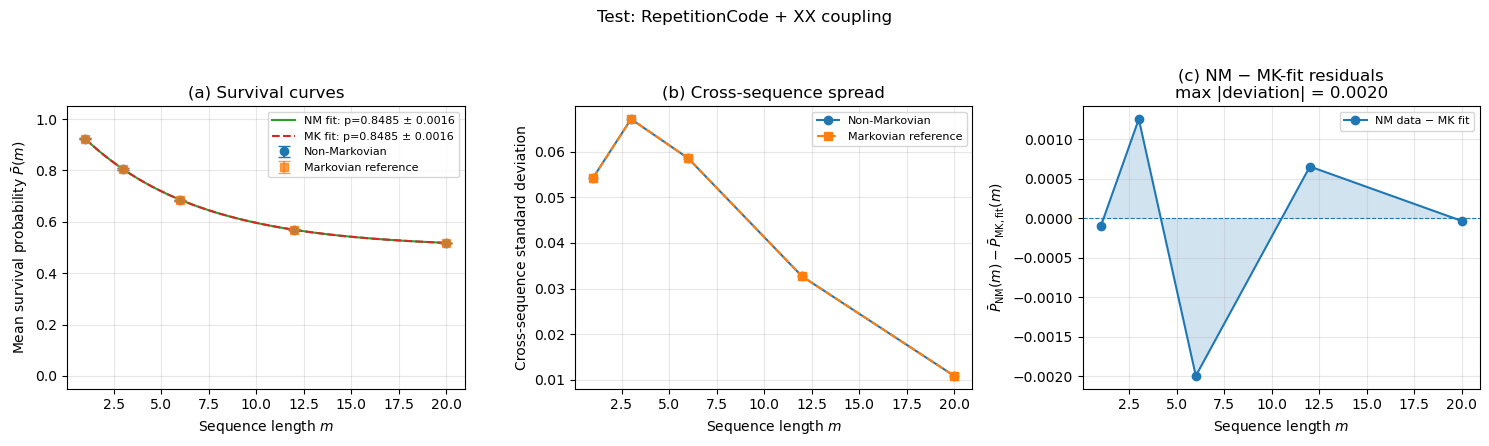

plot_comparison: 3-panel figure produced. OK


In [45]:
from logical_rb import plot_comparison

fig = plot_comparison(
    results_nm=results_nm,
    results_mk=results_mk,
    fit_nm=fit_nm,
    fit_mk=fit_mk,
    diag=diag,
    title="Test: RepetitionCode + XX coupling",
)

assert len(fig.axes) == 3, f"Expected 3 panels, got {len(fig.axes)}"
plt.show()
print("plot_comparison: 3-panel figure produced. OK")

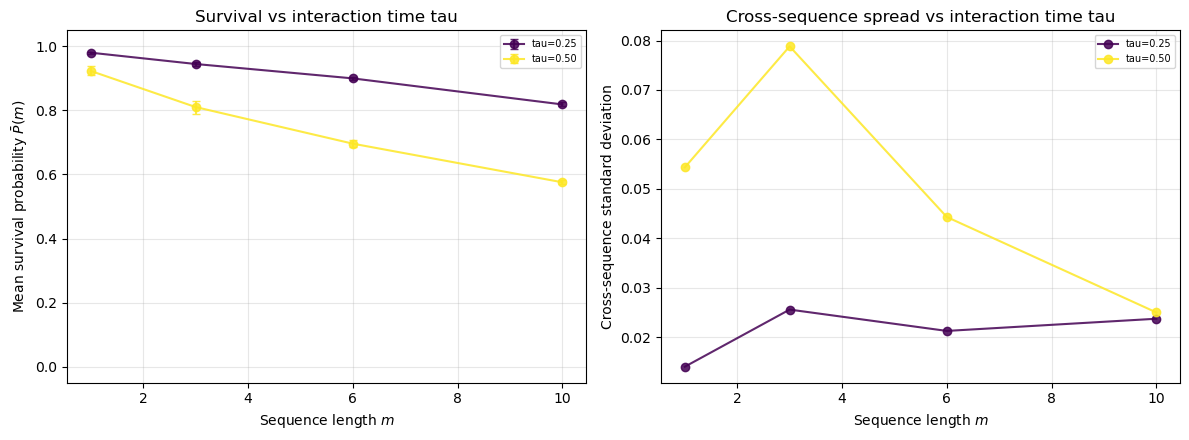

plot_correction_frequency_sweep: 2-panel figure produced. OK


In [46]:
from logical_rb import plot_correction_frequency_sweep

U_a = xx_coupling(n_sys=rep.n, n_E=1, g=0.4, tau=0.25)
U_b = xx_coupling(n_sys=rep.n, n_E=1, g=0.4, tau=0.5)

res_a = run_logical_rb([1,3,6,10], 15, rep, UnitarySENoise(U_a, 1), seed=3)
res_b = run_logical_rb([1,3,6,10], 15, rep, UnitarySENoise(U_b, 1), seed=3)

res_a["label"] = "tau=0.25"
res_b["label"] = "tau=0.50"

fig2 = plot_correction_frequency_sweep(
    sweep_results=[res_a, res_b],
    sweep_label="interaction time tau",
)

assert len(fig2.axes) == 2, f"Expected 2 panels, got {len(fig2.axes)}"
plt.show()
print("plot_correction_frequency_sweep: 2-panel figure produced. OK")

---
## 8. End-to-end: Steane code + ZX memory coupling

A self-contained mini-experiment that replicates the core of `demo_logical_rb.py`
at smaller scale, so you can see every step.

In [ ]:
from logical_rb.noise_models import hamiltonian_coupling
from logical_rb.operators import lift

steane  = SteaneCode()
n_E_s   = 1
n_total = steane.n + n_E_s   # 8 qubits

# H_SE = J Σ_k Z_k^S X_0^E  — entangles S and E even from |0>_E
J, tau = 0.25, 0.5
dim = 2**n_total
H_SE = np.zeros((dim, dim), dtype=complex)
X_E0 = lift(X, steane.n, n_total)
for k in range(steane.n):
    H_SE += J * (lift(Z, k, n_total) @ X_E0)

U_SE = hamiltonian_coupling(H_SE, tau)
check_unitary(U_SE, "U_SE (ZX memory)")
print(f"U_SE shape: {U_SE.shape}, unitary: OK")

noise_s = UnitarySENoise(U_SE, n_E_s)

lengths = [1, 2, 4, 8, 15]

res_nm = run_logical_rb(lengths, 20, steane, noise_s, reset_E=False, seed=42)
res_mk = run_logical_rb(lengths, 20, steane, noise_s, reset_E=True,  seed=42)

fit_nm = fit_rb_curve(res_nm)
fit_mk = fit_rb_curve(res_mk)
diag_s = non_markovian_diagnostics(res_nm, res_mk, fit_nm, fit_mk)

print(f"  NM: p={fit_nm['p']:.4f} ± {fit_nm['p_err']:.4f}")
print(f"  MK: p={fit_mk['p']:.4f} ± {fit_mk['p_err']:.4f}")
print(f"  p_gap (NM - MK) = {diag_s['p_gap']:.4f}")
print(f"  max NM-MK deviation = {diag_s['max_nm_mk_deviation']:.4f}")

fig_e2e = plot_comparison(
    results_nm=res_nm, results_mk=res_mk,
    fit_nm=fit_nm, fit_mk=fit_mk,
    diag=diag_s,
    title="Steane code — ZX memory coupling (mini demo)",
)
plt.show()
print("End-to-end Steane demo: OK")

U_SE shape: (256, 256), unitary: OK
